# 📊 Lab 22: Statistical Visuals with Seaborn

This project demonstrates statistical data visualization using Seaborn on the Titanic dataset.

## 🎯 Objectives
- Visualize distributions using histograms
- Identify outliers with boxplots
- Analyze density using violin plots
- Perform grouped analysis using hue
- Build subplot grids using row & col
- Generate insights from real-world data

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Seaborn:", sns.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Pandas:", pd.__version__)

Seaborn: 0.13.2
Matplotlib: 3.10.0
Pandas: 2.3.3


In [2]:
titanic = sns.load_dataset('titanic')

print("Dataset shape:", titanic.shape)
titanic.head()

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


We are using the built-in Titanic dataset from Seaborn, which contains passenger information including age, class, fare, and survival status.

In [3]:
titanic.info()
titanic.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 📈 Age Distribution

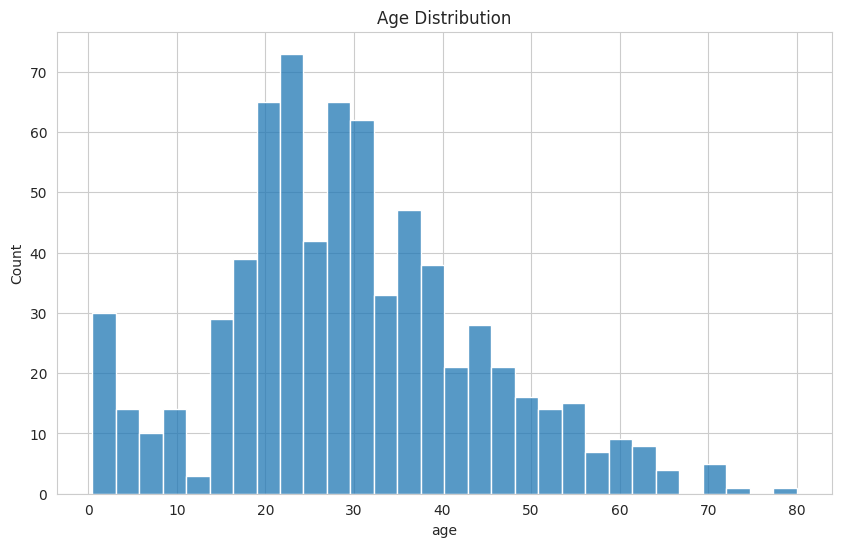

In [4]:
sns.histplot(data=titanic, x='age', bins=30)
plt.title('Age Distribution')
plt.show()

## 📦 Age vs Class

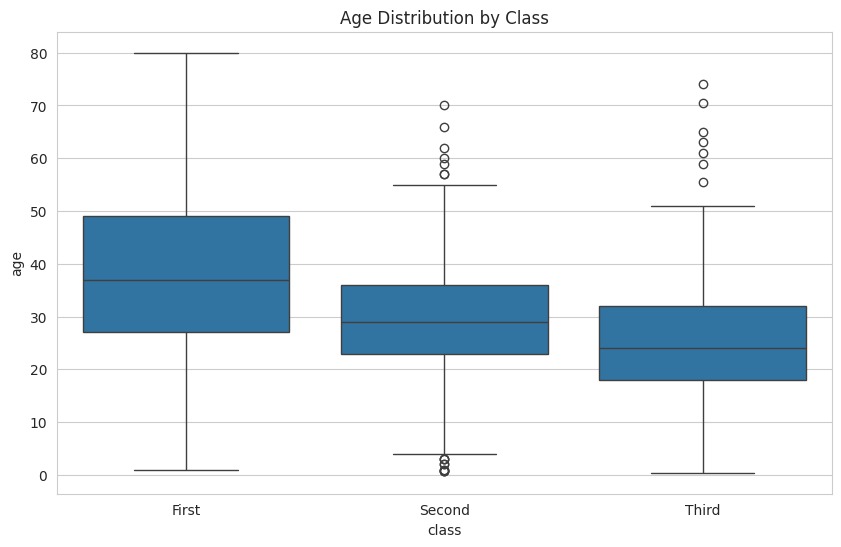

In [5]:
sns.boxplot(data=titanic, x='class', y='age')
plt.title('Age Distribution by Class')
plt.show()

## 🎻 Age Distribution by Gender

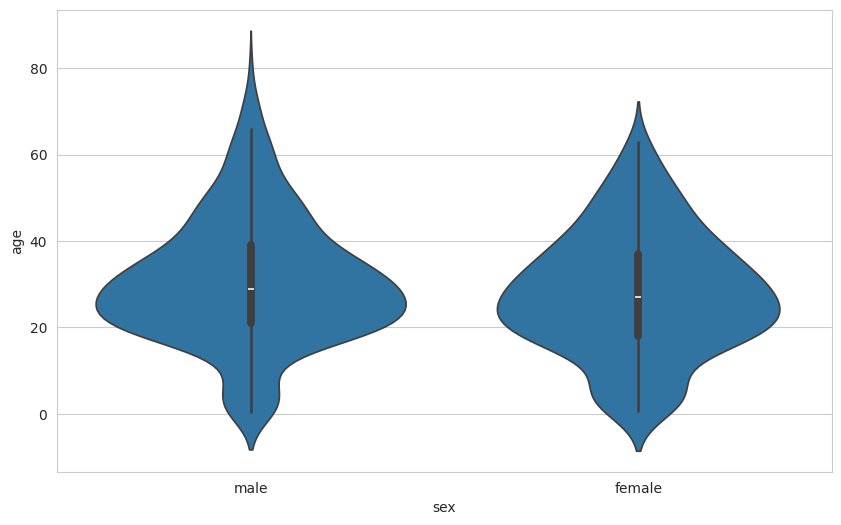

In [6]:
sns.violinplot(data=titanic, x='sex', y='age')
plt.show()

## 📊 Multi-Category Analysis

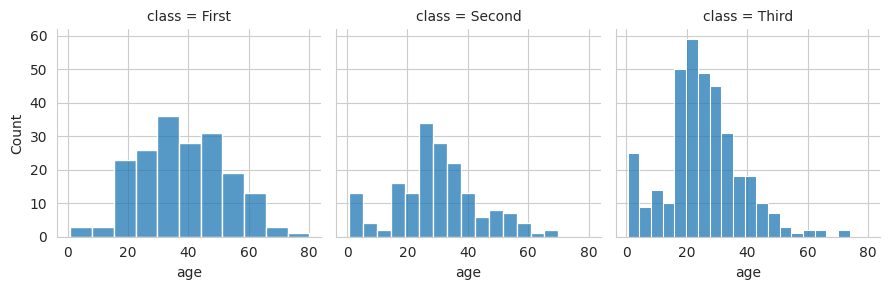

In [7]:
g = sns.FacetGrid(titanic, col='class')
g.map(sns.histplot, 'age')
plt.show()

## 📊 Dashboard Analysis

/tmp/ipykernel_55/1944719792.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival = titanic.groupby('class')['survived'].mean()


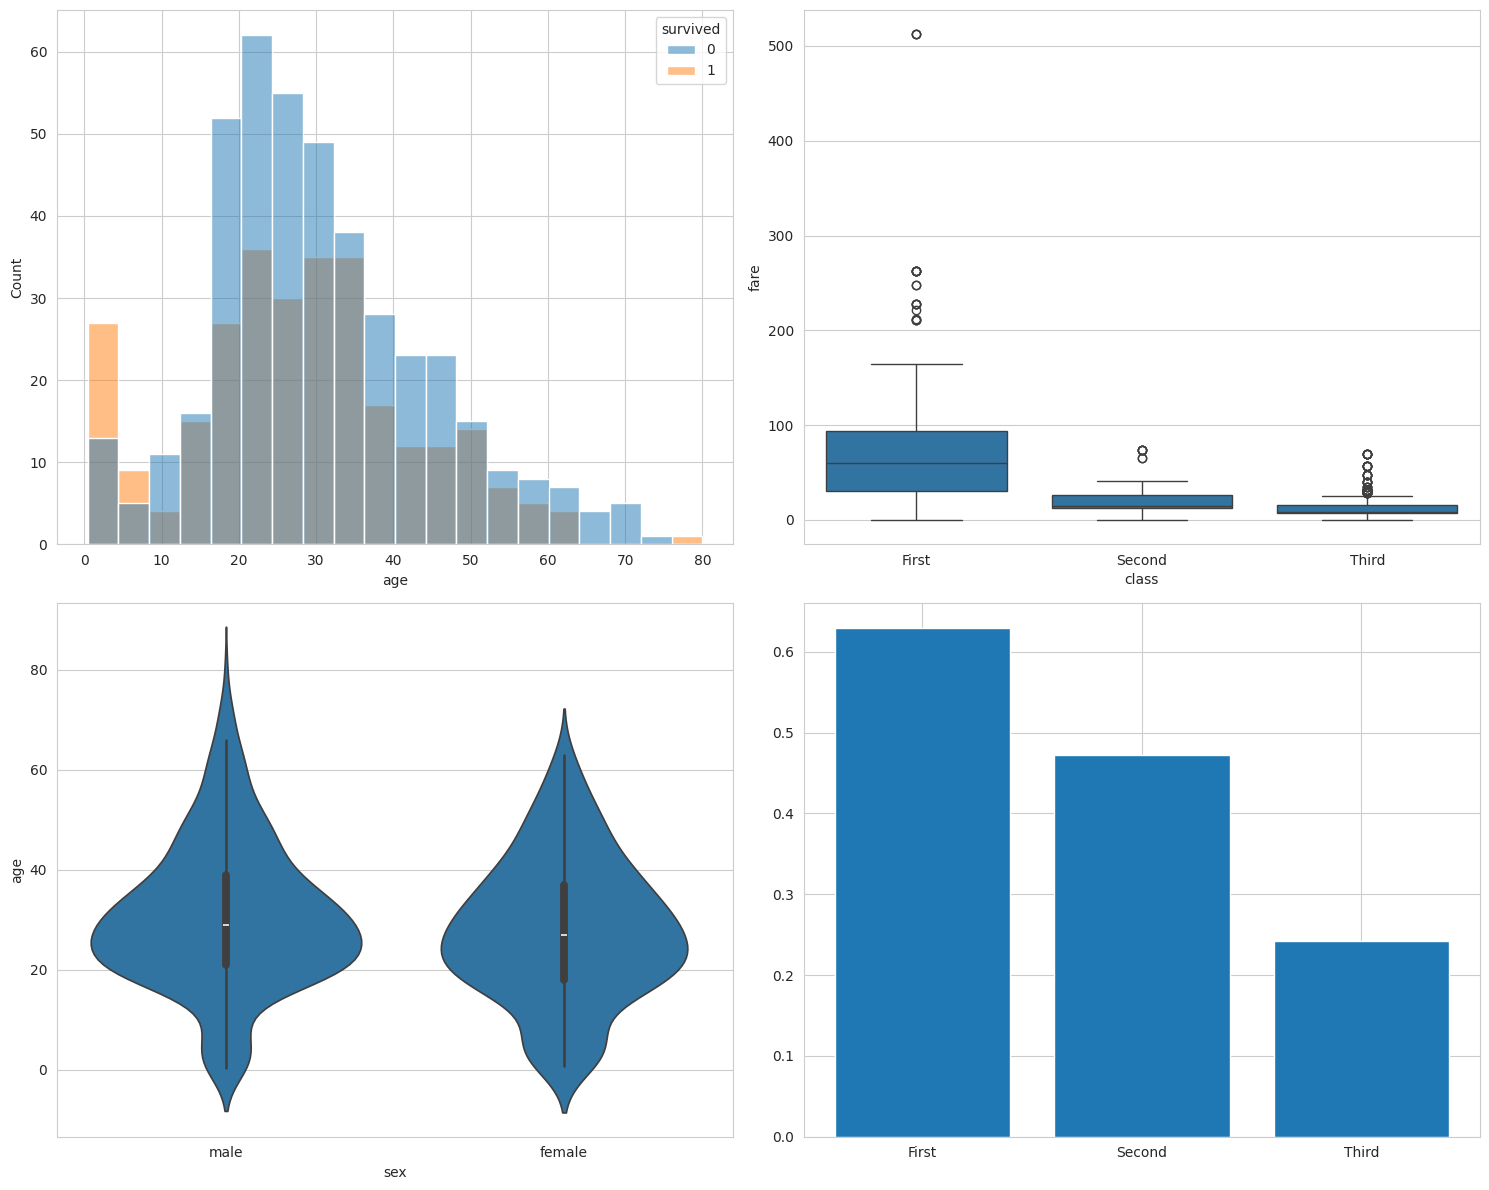

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.histplot(data=titanic, x='age', hue='survived', ax=axes[0,0])
sns.boxplot(data=titanic, x='class', y='fare', ax=axes[0,1])
sns.violinplot(data=titanic, x='sex', y='age', ax=axes[1,0])

survival = titanic.groupby('class')['survived'].mean()
axes[1,1].bar(survival.index, survival.values)

plt.tight_layout()
plt.show()

## 🔍 Key Insights

- Younger passengers had slightly higher survival rates
- First-class passengers had significantly higher survival chances
- Females had a much higher survival rate than males
- Higher fares are associated with higher survival probability

In [10]:
plt.savefig('/kaggle/working/titanic_analysis.png', dpi=300)

<Figure size 1000x600 with 0 Axes>